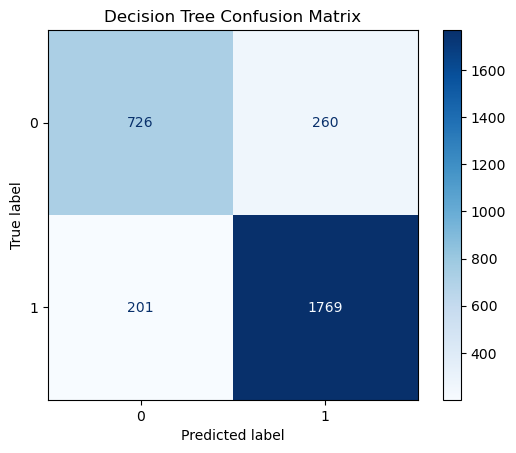

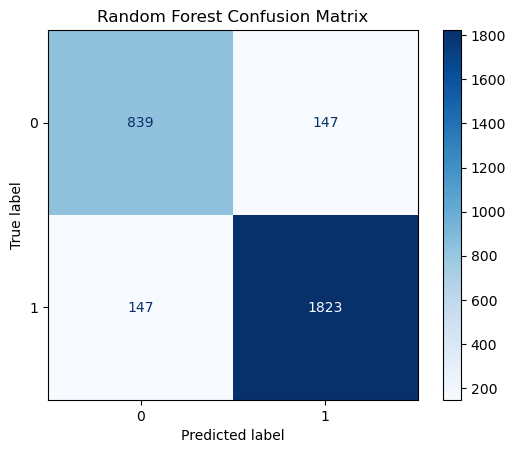

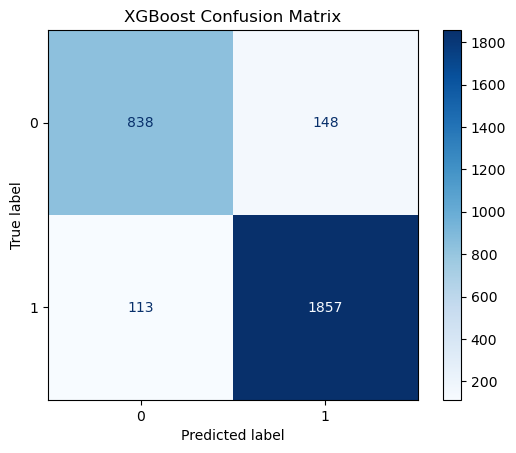

Fitting 5 folds for each of 36 candidates, totalling 180 fits


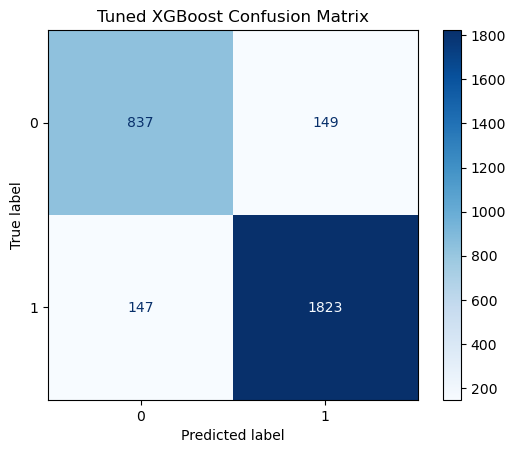

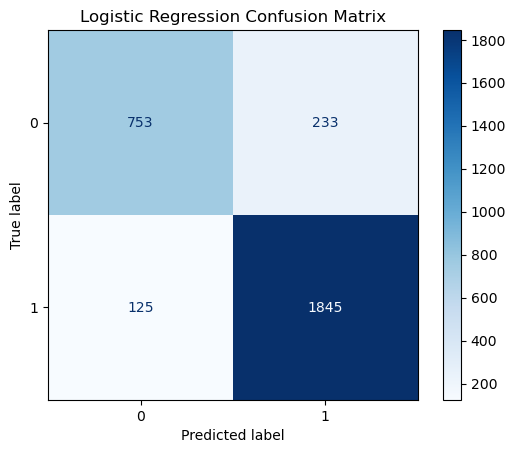


--- Model Performance Comparison Table ---
              Model  Accuracy  F1 Score  Recall (Class 0)  Recall (Class 1)
      Decision Tree  0.844046  0.884721          0.736308          0.897970
      Random Forest  0.900541  0.925381          0.850913          0.925381
            XGBoost  0.911705  0.934340          0.849899          0.942640
      Tuned XGBoost  0.899865  0.924911          0.848884          0.925381
Logistic Regression  0.878890  0.911561          0.763692          0.936548


In [3]:
# Logistic Regression and Decision Tree Models with Chi-Square Feature Selection (95% Confidence, NaNs Dropped)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFpr, chi2

# Load dataset
df = pd.read_csv('final.csv')

# Drop rows with missing values
df = df.dropna()

# Drop unnecessary columns
drop_cols = ['COHORT_OL', 'TAKING_PD_RXS_OL', 'NUPSOURC_OL']
X = df.drop(columns=drop_cols, errors='ignore')
y = df['COHORT_OL']

# Ensure X is non-negative (required for chi2)
X = X.select_dtypes(include=[np.number])
X = X[X.columns[(X >= 0).all()]]

# Select features using Chi-Square test with 95% confidence level (alpha=0.05)
selector = SelectFpr(score_func=chi2, alpha=0.05)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
X = X[selected_features]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []

def evaluate_model(name, y_test, y_pred):
    report = classification_report(y_test, y_pred, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall_0 = report['0']['recall']
    recall_1 = report['1']['recall']
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1 Score': f1,
        'Recall (Class 0)': recall_0,
        'Recall (Class 1)': recall_1
    })

# --- Decision Tree ---
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
evaluate_model("Decision Tree", y_test, y_pred_dt)

cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt).plot(cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.show()

# --- Random Forest ---
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
evaluate_model("Random Forest", y_test, y_pred_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

# --- XGBoost (Default) ---
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
evaluate_model("XGBoost", y_test, y_pred_xgb)

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb).plot(cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.show()

# --- Tuned XGBoost with Class Imbalance ---
total = y_train.shape[0]
pos = y_train.sum()
neg = total - pos
scale_pos_weight = neg / pos

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [5, 7],
    'learning_rate': [0.1, 0.5, 0.7],
    'reg_lambda': [0.5, 1, 10],
}
xgb_tuned = XGBClassifier(use_label_encoder=False, eval_metric='auc', scale_pos_weight=scale_pos_weight, verbosity=0)
grid_xgb = GridSearchCV(xgb_tuned, param_grid, scoring='recall', cv=5, n_jobs=-1, verbose=2)
grid_xgb.fit(X_train, y_train)
y_pred_xgb_tuned = grid_xgb.best_estimator_.predict(X_test)
evaluate_model("Tuned XGBoost", y_test, y_pred_xgb_tuned)

cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)
ConfusionMatrixDisplay(cm_xgb_tuned).plot(cmap='Blues')
plt.title("Tuned XGBoost Confusion Matrix")
plt.show()

# --- Logistic Regression ---
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
evaluate_model("Logistic Regression", y_test, y_pred_log)

cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log).plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# --- Final Model Comparison Table ---
comparison_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison Table ---")
print(comparison_df.to_string(index=False))


In [4]:
# Determine Top 30 Features for All Models and Re-evaluate

from sklearn.feature_selection import SelectKBest, f_classif

# Reuse previous cleaned dataset
X_full = df[selected_features]
y_full = y

# Define models to analyze
model_objects = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    'Tuned XGBoost': grid_xgb.best_estimator_
}

comparison_top30 = []

# Evaluate model on top 30 features
for name, model in model_objects.items():
    selector_kbest = SelectKBest(score_func=f_classif, k=40)
    X_kbest = selector_kbest.fit_transform(X_full, y_full)
    selected_names = X_full.columns[selector_kbest.get_support()]
    X_selected = X_full[selected_names]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y_full, test_size=0.2, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)

    comparison_top30.append({
        'Model': name + ' (Top 30)',
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Recall (Class 0)': report['0']['recall'],
        'Recall (Class 1)': report['1']['recall']
    })

# Add original full-featured model results
comparison_top30.extend(results)

# Combine and display
comparison_df_all = pd.DataFrame(comparison_top30)
print("\n--- Full vs Top-30 Feature Model Comparison Table ---")
print(comparison_df_all.to_string(index=False))



--- Full vs Top-30 Feature Model Comparison Table ---
                       Model  Accuracy  F1 Score  Recall (Class 0)  Recall (Class 1)
Logistic Regression (Top 30)  0.860622  0.898771          0.725152          0.928426
      Decision Tree (Top 30)  0.829499  0.872340          0.740365          0.874112
      Random Forest (Top 30)  0.890054  0.917071          0.845842          0.912183
            XGBoost (Top 30)  0.893437  0.920354          0.832657          0.923858
      Tuned XGBoost (Top 30)  0.883288  0.911516          0.845842          0.902030
               Decision Tree  0.844046  0.884721          0.736308          0.897970
               Random Forest  0.900541  0.925381          0.850913          0.925381
                     XGBoost  0.911705  0.934340          0.849899          0.942640
               Tuned XGBoost  0.899865  0.924911          0.848884          0.925381
         Logistic Regression  0.878890  0.911561          0.763692          0.936548
